# Synthetic → Real Patient Tumour Parameter Prediction
Train on all 250 synthetic patients, predict Dw and rho for 33 real patients using segmentation masks only.

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths ────────────────────────────────────────────────────────────────────
SYNTH_ROOT = Path("synthetic_runs1T_FK_2c")   # folder with synthetic1T_run* dirs
REAL_ROOT  = Path("RHUH-GBM_nii_v1")          # root-level folder with RHUH-0001 … RHUH-00xx dirs

# ── Config ───────────────────────────────────────────────────────────────────
TARGET_KEYS = ("Dw", "rho")
OUT_SHAPE   = (96, 96, 96)
BATCH_SIZE  = 8
EPOCHS      = 300
SEED        = 42

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("Device:", device)

Device: cuda


In [2]:
random.seed(SEED)

synth_samples = sorted([p for p in SYNTH_ROOT.glob("synthetic1T_run*") if p.is_dir()])
print(f"Total synthetic samples: {len(synth_samples)}")

# Use ALL synthetic samples for training — real patients are the held-out set
train = list(synth_samples)
random.shuffle(train)
print(f"Training on {len(train)} synthetic samples")


Total synthetic samples: 250
Training on 250 synthetic samples


In [3]:
def get_y(sample_dir):
    p = json.loads((sample_dir / "parameters.json").read_text())
    vals = []
    for k in TARGET_KEYS:
        v = float(p[k])
        if k == "Dw":
            v = np.log(v)   # log-space for Dw
        vals.append(v)
    return np.array(vals, dtype=np.float32)

Y_train = np.stack([get_y(s) for s in train], axis=0)
Y_MEAN  = Y_train.mean(axis=0)
Y_STD   = Y_train.std(axis=0) + 1e-6

print("Y_MEAN:", Y_MEAN)
print("Y_STD :", Y_STD)


Y_MEAN: [0.3477533  0.38303345]
Y_STD : [0.9153898  0.23412253]


In [4]:
def read_nii(path):
    img = sitk.ReadImage(str(path))
    return sitk.GetArrayFromImage(img).astype(np.float32)   # (D, H, W)

def bbox_from_mask(mask, margin=12):
    idx = np.argwhere(mask)
    if idx.size == 0:
        return None
    z0, y0, x0 = idx.min(axis=0)
    z1, y1, x1 = idx.max(axis=0) + 1
    z0 = max(z0 - margin, 0);  y0 = max(y0 - margin, 0);  x0 = max(x0 - margin, 0)
    z1 = min(z1 + margin, mask.shape[0])
    y1 = min(y1 + margin, mask.shape[1])
    x1 = min(x1 + margin, mask.shape[2])
    return (z0, z1, y0, y1, x0, x1)

def crop(arr, bb):
    z0, z1, y0, y1, x0, x1 = bb
    return arr[z0:z1, y0:y1, x0:x1]

def resize_3d(arr, out_shape=(96, 96, 96)):
    t = torch.from_numpy(arr)[None, None, ...]
    t = F.interpolate(t, size=out_shape, mode="trilinear", align_corners=False)
    return t[0, 0].numpy()


In [5]:
class TumorParamDatasetCached(Dataset):
    """Segmentation-only cached dataset for synthetic patients (has labels)."""

    def __init__(self, sample_dirs, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS, verbose=True):
        self.cache = []
        if verbose:
            print(f"Caching {len(sample_dirs)} samples…")
        for i, sd in enumerate(sample_dirs):
            self.cache.append(self._load_one(sd))
            if verbose and (i + 1) % 25 == 0:
                print(f"  {i+1}/{len(sample_dirs)}")
        if verbose:
            print("Done.")

    def __len__(self):  return len(self.cache)
    def __getitem__(self, idx): return self.cache[idx]

    def _load_one(self, sd):
        # --- label ---
        params = json.loads((sd / "parameters.json").read_text())
        vals = []
        for k in TARGET_KEYS:
            v = float(params[k])
            if k == "Dw":
                v = np.log(v)
            vals.append(v)
        y = torch.tensor((np.array(vals, dtype=np.float32) - Y_MEAN) / Y_STD,
                         dtype=torch.float32)

        # --- input: binary segmentation mask ---
        segm = read_nii(sd / "segm.nii.gz")
        mask = (segm > 0).astype(np.float32)
        bb   = bbox_from_mask(mask, margin=12)
        if bb is not None:
            mask = crop(mask, bb)
        mask = resize_3d(mask, OUT_SHAPE)

        x = torch.from_numpy(mask[None, ...]).float()
        return x, y


In [6]:
class RealPatientDataset(Dataset):
    """
    Loads segmentation mask from real patients (no labels, inference only).
    Uses only subfolder 0/ which corresponds to the baseline time point.
    """

    def __init__(self, patient_dirs, out_shape=OUT_SHAPE, verbose=True):
        self.patient_dirs = patient_dirs
        self.cache = []
        if verbose:
            print(f"Loading {len(patient_dirs)} real patients (subfolder 0 only)…")
        for i, pd_ in enumerate(patient_dirs):
            self.cache.append(self._load_one(pd_))
            if verbose:
                print(f"  loaded {pd_.name}")
        if verbose:
            print("Done.")

    def __len__(self):  return len(self.cache)
    def __getitem__(self, idx): return self.cache[idx]

    def _load_one(self, pd_):
        sub_dir = pd_ / "0"
        hits = list(sub_dir.glob("*segmentations.nii.gz")) if sub_dir.exists() else []

        if hits:
            arr      = read_nii(hits[0])
            mask     = (arr > 0).astype(np.float32)
        else:
            print(f"  WARNING: no segmentation found in {pd_.name}/0, using zeros")
            mask = np.zeros(OUT_SHAPE, dtype=np.float32)

        bb = bbox_from_mask(mask, margin=12)
        if bb is not None:
            mask = crop(mask, bb)
        mask = resize_3d(mask, OUT_SHAPE)

        return torch.from_numpy(mask[None, ...]).float()


In [7]:
class CNN3DRegressor(nn.Module):
    def __init__(self, in_channels=1, out_dim=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(in_channels, 32, 3, padding=1),
            nn.BatchNorm3d(32), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(128, 256, 3, padding=1),
            nn.BatchNorm3d(256), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.head(self.features(x))


In [8]:
train_ds     = TumorParamDatasetCached(train, verbose=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
print(f"Train batches: {len(train_loader)}")


Caching 250 samples…
  25/250
  50/250
  75/250
  100/250
  125/250
  150/250
  175/250
  200/250
  225/250
  250/250
Done.
Train batches: 32


In [9]:
model    = CNN3DRegressor(in_channels=1, out_dim=len(TARGET_KEYS)).to(device)
opt      = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler   = GradScaler("cpu")
loss_fn  = nn.MSELoss()
mae_fn   = lambda p, y: (p - y).abs().mean()

best_mse, best_state, best_epoch = float("inf"), None, -1
train_mse_log = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = tr_mae = 0.0

    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with autocast("cpu"):
            pred = model(x)
            loss = loss_fn(pred, y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(opt)
        scaler.update()
        tr_loss += loss.item()
        tr_mae  += mae_fn(pred.detach(), y).item()

    epoch_mse = tr_loss / len(train_loader)
    epoch_mae = tr_mae  / len(train_loader)
    train_mse_log.append(epoch_mse)

    if epoch_mse < best_mse:
        best_mse   = epoch_mse
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train MSE {epoch_mse:.4f}  MAE {epoch_mae:.4f}"
              f" | best {best_mse:.4f} @ {best_epoch:03d}")

model.load_state_dict(best_state)
print(f"\n✅ Best model: epoch {best_epoch}  train MSE {best_mse:.6f}")


Epoch 001 | train MSE 0.7765  MAE 0.7041 | best 0.7765 @ 001
Epoch 025 | train MSE 0.4216  MAE 0.4972 | best 0.4216 @ 025
Epoch 050 | train MSE 0.2764  MAE 0.4142 | best 0.2473 @ 047
Epoch 075 | train MSE 0.2332  MAE 0.3800 | best 0.1857 @ 064
Epoch 100 | train MSE 0.1679  MAE 0.3210 | best 0.1679 @ 100
Epoch 125 | train MSE 0.1700  MAE 0.3201 | best 0.1588 @ 116
Epoch 150 | train MSE 0.1748  MAE 0.3271 | best 0.1322 @ 139
Epoch 175 | train MSE 0.1330  MAE 0.2848 | best 0.1302 @ 174
Epoch 200 | train MSE 0.1554  MAE 0.3146 | best 0.1218 @ 192
Epoch 225 | train MSE 0.1365  MAE 0.2967 | best 0.1127 @ 206
Epoch 250 | train MSE 0.1115  MAE 0.2596 | best 0.1044 @ 249
Epoch 275 | train MSE 0.1123  MAE 0.2639 | best 0.1001 @ 258
Epoch 300 | train MSE 0.1298  MAE 0.2787 | best 0.0974 @ 288

✅ Best model: epoch 288  train MSE 0.097416


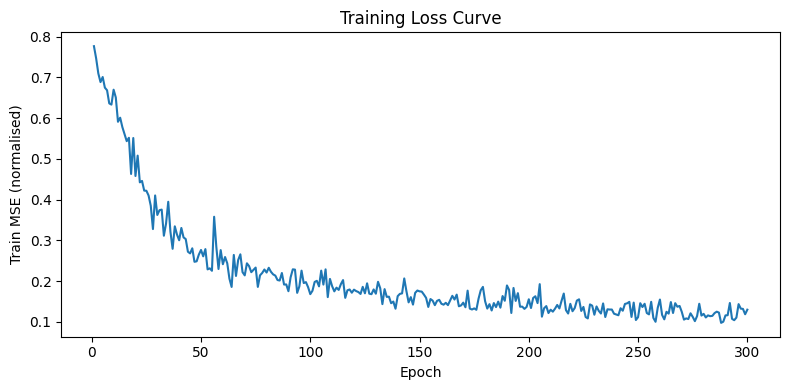

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_mse_log) + 1), train_mse_log)
plt.xlabel("Epoch")
plt.ylabel("Train MSE (normalised)")
plt.title("Training Loss Curve")
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()


In [11]:
torch.save({
    "model_state": model.state_dict(),
    "target_keys": TARGET_KEYS,
    "out_shape"  : OUT_SHAPE,
    "y_mean"     : Y_MEAN,
    "y_std"      : Y_STD,
}, "dcnn_param_model_synth2real.pt")

print("Model saved → dcnn_param_model_synth2real.pt")


Model saved → dcnn_param_model_synth2real.pt


In [12]:
real_patient_dirs = sorted([p for p in REAL_ROOT.iterdir() if p.is_dir()])
print(f"Found {len(real_patient_dirs)} real patient folders")

real_ds     = RealPatientDataset(real_patient_dirs, verbose=True)
real_loader = DataLoader(real_ds, batch_size=1, shuffle=False, num_workers=0)


Found 40 real patient folders
Loading 40 real patients (subfolder 0 only)…
  loaded RHUH-0001
  loaded RHUH-0002
  loaded RHUH-0003
  loaded RHUH-0004
  loaded RHUH-0005
  loaded RHUH-0006
  loaded RHUH-0007
  loaded RHUH-0008
  loaded RHUH-0009
  loaded RHUH-0010
  loaded RHUH-0011
  loaded RHUH-0012
  loaded RHUH-0013
  loaded RHUH-0014
  loaded RHUH-0015
  loaded RHUH-0016
  loaded RHUH-0017
  loaded RHUH-0018
  loaded RHUH-0019
  loaded RHUH-0020
  loaded RHUH-0021
  loaded RHUH-0022
  loaded RHUH-0023
  loaded RHUH-0024
  loaded RHUH-0025
  loaded RHUH-0026
  loaded RHUH-0027
  loaded RHUH-0028
  loaded RHUH-0029
  loaded RHUH-0030
  loaded RHUH-0031
  loaded RHUH-0032
  loaded RHUH-0033
  loaded RHUH-0034
  loaded RHUH-0035
  loaded RHUH-0036
  loaded RHUH-0037
  loaded RHUH-0038
  loaded RHUH-0039
  loaded RHUH-0040
Done.


In [13]:
model.eval()
results = []

with torch.no_grad():
    for i, x in enumerate(real_loader):
        x        = x.to(device, non_blocking=True)
        pred_norm = model(x).cpu().numpy()[0]

        # Denormalise
        pred_raw = pred_norm * Y_STD + Y_MEAN

        row = {"patient": real_patient_dirs[i].name}
        for j, k in enumerate(TARGET_KEYS):
            v = float(pred_raw[j])
            if k == "Dw":
                v = np.exp(v)   # undo log-space
            row[k] = v

        results.append(row)
        print(f"{row['patient']:20s}  Dw={row['Dw']:.5f}  rho={row['rho']:.5f}")

df = pd.DataFrame(results)
df.to_csv("real_patient_predictions.csv", index=False)
print("\nPredictions saved → real_patient_predictions.csv")
print(df.to_string(index=False))


RHUH-0001             Dw=1.63186  rho=0.09136
RHUH-0002             Dw=0.35726  rho=0.15367
RHUH-0003             Dw=0.60548  rho=0.07826
RHUH-0004             Dw=0.44629  rho=0.20288
RHUH-0005             Dw=1.27390  rho=0.08159
RHUH-0006             Dw=0.62193  rho=0.32267
RHUH-0007             Dw=0.29481  rho=0.27991
RHUH-0008             Dw=0.61035  rho=0.25064
RHUH-0009             Dw=0.85242  rho=0.20462
RHUH-0010             Dw=0.48569  rho=0.10214
RHUH-0011             Dw=1.53988  rho=0.21717
RHUH-0012             Dw=0.53380  rho=0.24466
RHUH-0013             Dw=0.94409  rho=0.26195
RHUH-0014             Dw=1.06503  rho=0.22649
RHUH-0015             Dw=1.70653  rho=0.10449
RHUH-0016             Dw=1.34248  rho=0.08260
RHUH-0017             Dw=1.27369  rho=0.11486
RHUH-0018             Dw=0.56356  rho=0.21501
RHUH-0019             Dw=0.55684  rho=0.24554
RHUH-0020             Dw=0.57343  rho=0.20944
RHUH-0021             Dw=0.73405  rho=0.13894
RHUH-0022             Dw=0.65921  

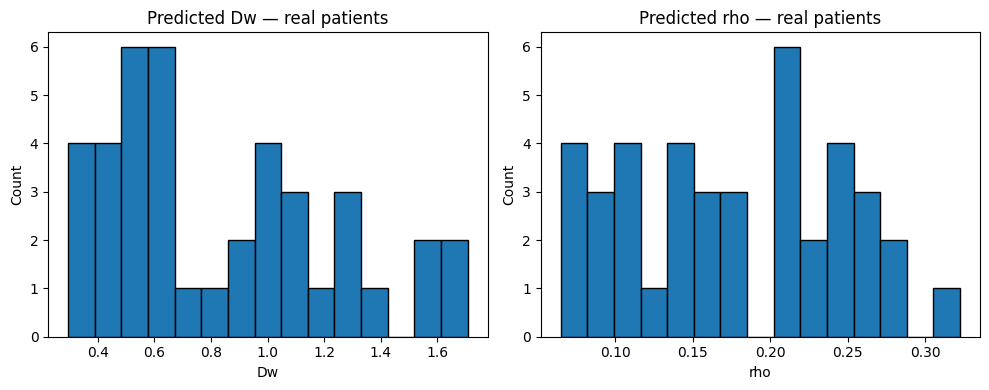

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, k in zip(axes, TARGET_KEYS):
    ax.hist(df[k], bins=15, edgecolor="black")
    ax.set_title(f"Predicted {k} — real patients")
    ax.set_xlabel(k)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("real_patient_prediction_distributions.png", dpi=150)
plt.show()
